# Tutorial 3: Running Quantization-Aware Training (QAT) on Bert

In this tutorial, we'll build on top of Tutorial 2 by taking the Bert model fine tuned for sequence classification and running Mase's quantization pass. First, we'll run simple Post-Training Quantization (PTQ) and see how much accuracy drops. Then, we'll run some further training iterations of the quantized model (i.e. QAT) and see whether the accuracy of the trained quantized model approaches the accuracy of the original (full-precision) model.

In [ ]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [2]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on LoRA Finetuning, run the following cell to import the fine tuned checkpoint.

In [3]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab0/tutorial_2_lora")

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


## Post-Training Quantization (PTQ)

Here, we simply quantize the model and evaluate the effect in its accuracy. First, let's evaluate the model accuracy before quantization (if you're coming from Tutorial 2, this should be the same as the post-LoRA evaluation accuracy). As seen in Tutorial 2, we can use the `get_tokenized_dataset` and `get_trainer` utilities to generate a HuggingFace `Trainer` instance for training and evaluation.

In [4]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:04<00:00, 11462.81 examples/s]
/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83756


To run the quantization pass, we pass a quantization configuration dictionary as argument. This defines the quantization mode, numerical format and precision for each operator in the graph. We'll run the quantization in "by type" mode, meaning nodes are quantized according to their `mase_op`. Other modes include by name and by regex name. We'll quantize all activations, weights and biases in the model to fixed-point with the same precision. This may be sub-optimal, but works as an example. In future tutorials, we'll see how to run the `search` flow in `Mase` to find optimal quantization configurations to minimize accuracy loss.

In [5]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

Let's evaluate the immediate effect of quantization on the model accuracy.

In [6]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.82304


We can save the current checkpoint for future reference (optional).

In [7]:
from pathlib import Path
!mkdir -p /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1
mg.export(f"/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_ptq")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
INFO     Exporting MaseGraph to /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_ptq.pt, /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_ptq.mz
INFO     Exporting GraphModule to /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_ptq.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_ptq.mz


## Quantization-Aware Training (QAT)

You should have seen in the last section that quantization can lead to a significant drop in accuracy. Next, we'll run QAT to evaluate whether this performance gap can be reduced. To run QAT in Mase, all you need to do is include the model back in your training loop after running the quantization pass.

In [8]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Step,Training Loss
500,0.398300
1000,0.388200
1500,0.404500
2000,0.388600
2500,0.382900
3000,0.399100


Evaluation accuracy: 0.8444


We can see the accuracy of the quantized model can match (or sometimes exceed) the full precision model, with a much lower memory requirement to store the weights. Finally, save the final checkpoint for future tutorials.

In [9]:
from pathlib import Path

mg.export(f"/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat")

INFO     Exporting MaseGraph to /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat.pt, /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat.mz
INFO     Exporting GraphModule to /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab1/tutorial_3_qat.mz


1: In Tutorial 3, you quantized every Linear layer in the model to the provided configuration. Now, explore a range of fixed point widths from 4 to 32.

- **a** Plot a figure where the x-axis is the fixed point width and the y-axis is the highest achieved accuracy on the IMDb dataset, following the procedure in Tutorial 3.

- **b** Plot separate curves for PTQ and QAT at each precision to show the effect of post-quantization finetuning.

In [13]:
import matplotlib.pyplot as plt

def quant_config(int_width=8, int_frac_width=4):
    return {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": int_width,
                "data_in_frac_width": int_frac_width,
                # weight
                "weight_width": int_width,
                "weight_frac_width": int_frac_width,
                # bias
                "bias_width": int_width,
                "bias_frac_width": int_frac_width,
            }
        },
    }

def quant_sweep(int_widths=range(4,32)):
    accuracies = []
    for int_width in int_widths:
        mg = MaseGraph.from_checkpoint(f"/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab0/tutorial_2_lora")
        trainer = get_trainer(
            model=mg.model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
        )
        print(f"Quantizing with int width {int_width} and int frac width {int_width//2}...")
        quantization_config = quant_config(int_width=int_width, int_frac_width=int_width//2)
        mg_quantized, _ = passes.quantize_transform_pass(
            mg,
            pass_args=quantization_config,
        )
        trainer.model = mg_quantized.model
        eval_results = trainer.evaluate()
        print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")
        accuracies.append(eval_results['eval_accuracy'])
    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(int_widths, accuracies, marker='o')
    plt.title('Quantization Sweep: Accuracy vs Integer Width')
    plt.xlabel('Integer Width (bits)')
    plt.ylabel('Evaluation Accuracy')
    plt.xticks(int_widths)
    plt.grid()
    plt.show()


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


Quantizing with int width 4 and int frac width 2...


/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


Evaluation accuracy: 0.5
Quantizing with int width 5 and int frac width 2...


...

/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


Evaluation accuracy: 0.83752
Quantizing with int width 31 and int frac width 15...


/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83752


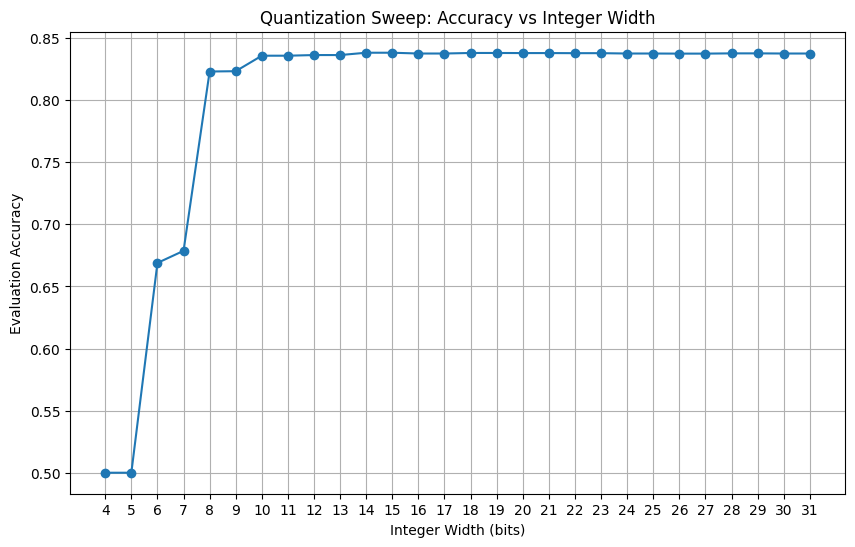

In [14]:
quant_sweep()

In [22]:
import matplotlib.pyplot as plt
import chop.passes as passes

def quant_train_sweep(int_widths=range(4, 32),frac_rule=lambda w: w // 2,qat_epochs=1):

    ptq_accs = []
    qat_accs = []

    for int_width in int_widths:
        int_frac = frac_rule(int_width)
        print(f"\n=== width={int_width}, frac={int_frac} ===")

        # PTQ
        mg = MaseGraph.from_checkpoint(
            "/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab0/tutorial_2_lora"
        )
        trainer_ptq = get_trainer(
            model=mg.model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
        )

        print(f"[PTQ] Quantizing (width={int_width}, frac={int_frac}) then evaluate...")
        quantization_config_ptq = quant_config(int_width=int_width, int_frac_width=int_frac)
        mg_ptq, _ = passes.quantize_transform_pass(mg, pass_args=quantization_config_ptq)

        trainer_ptq.model = mg_ptq.model
        ptq_eval = trainer_ptq.evaluate()
        ptq_acc = ptq_eval["eval_accuracy"]
        print(f"[PTQ] eval_accuracy = {ptq_acc:.6f}")
        ptq_accs.append(ptq_acc)

        # QAT
        mg2 = MaseGraph.from_checkpoint(
            "/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/lab0/tutorial_2_lora"
        )
        trainer_qat = get_trainer(
            model=mg2.model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
        )

        print(f"[QAT] Quantizing then finetune for {qat_epochs} epoch(s)...")
        quantization_config_qat = quant_config(int_width=int_width, int_frac_width=int_frac)
        mg_qat, _ = passes.quantize_transform_pass(mg2, pass_args=quantization_config_qat)
        
        trainer_qat.model = mg_qat.model
        device = trainer_qat.args.device
        trainer_qat.model.to(device)
        trainer_qat.model.train()
        trainer_qat.train()


        qat_eval = trainer_qat.evaluate()
        best_acc = qat_eval["eval_accuracy"]

        print(f"[QAT] best achieved accuracy = {best_acc:.6f}")
        qat_accs.append(best_acc)

    plt.figure(figsize=(10, 6))
    plt.plot(list(int_widths), ptq_accs, marker="o", label="PTQ (eval after quant)")
    plt.plot(list(int_widths), qat_accs, marker="o", label=f"QAT (finetune {qat_epochs} ep, best achieved)")
    plt.title("PTQ vs QAT: Accuracy vs Fixed-Point Width")
    plt.xlabel("Fixed-Point Width (bits)")
    plt.ylabel("Accuracy")
    plt.xticks(list(int_widths))
    plt.grid(True)
    plt.legend()
    plt.show()

    return ptq_accs, qat_accs


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.



=== width=4, frac=2 ===
[PTQ] Quantizing (width=4, frac=2) then evaluate...


/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


[PTQ] eval_accuracy = 0.500000
[QAT] Quantizing then finetune for 1 epoch(s)...


...

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


[PTQ] eval_accuracy = 0.837520
[QAT] Quantizing then finetune for 1 epoch(s)...


/home/roy/Documents/STUDY/IC/YEAR4_TERM2/ADLS/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.383400
1000,0.376200
1500,0.394200
2000,0.375300
2500,0.375400
3000,0.391600


[QAT] best achieved accuracy = 0.845160


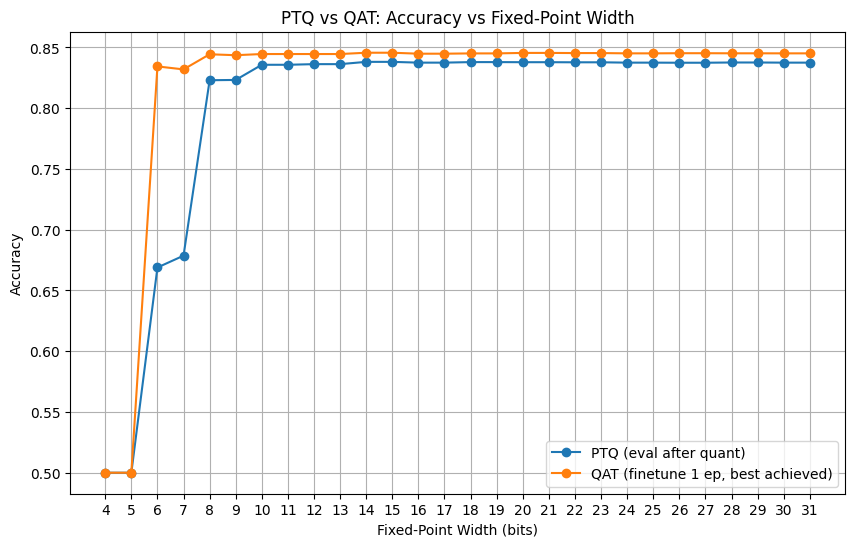

([0.5,
  0.5,
  0.66892,
  0.67864,
  0.82304,
  0.82328,
  0.83576,
  0.83576,
  0.83628,
  0.83628,
  0.83816,
  0.83816,
  0.83752,
  0.83752,
  0.83796,
  0.83796,
  0.83788,
  0.83788,
  0.8378,
  0.8378,
  0.83752,
  0.83752,
  0.83744,
  0.83744,
  0.83764,
  0.83764,
  0.83752,
  0.83752],
 [0.5,
  0.5,
  0.8344,
  0.83196,
  0.8444,
  0.84364,
  0.8446,
  0.8446,
  0.8446,
  0.8446,
  0.84568,
  0.84568,
  0.84488,
  0.84488,
  0.84512,
  0.84512,
  0.84552,
  0.84552,
  0.8454,
  0.8454,
  0.84516,
  0.84516,
  0.84528,
  0.84528,
  0.8452,
  0.8452,
  0.84516,
  0.84516])

In [23]:
quant_train_sweep()